### Nesse arquivo, veremos um exemplo de como uma decision tree(árvore de decisão) consegue identificar padrões com base nas observações da base de treino e assim classificar quais pessoas sobreviveram ou não.

In [1]:
# Instalação de pacotes
pacotes <- c('titanic',    # carrega a base original titanic_treino 
             'tidyverse',  # Pacote básico de datawrangling
             'rpart',      # Biblioteca de árvores
             'rpart.plot', # Conjunto com Rpart, plota a parvore
             'gtools',     # funções auxiliares como quantcut,
             'Rmisc',      # carrega a função sumarySE para a descritiva
             'scales',     # importa paletas de cores
             'caret',      # Funções úteis para machine learning
             'plotly'      # Biblioteca p/ plotagem de gráficos
             
             )

if(sum(as.numeric(!pacotes %in% installed.packages())) != 0){
  instalador <- pacotes[!pacotes %in% installed.packages()]
  for(i in 1:length(instalador)) {
    install.packages(instalador, dependencies = T)
    break()}
  sapply(pacotes, require, character = T) 
} else {
  sapply(pacotes, require, character = T) 
}

Loading required package: titanic

Loading required package: tidyverse

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.5     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.0.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: rpart

Loading required package: rpart.plot

Loading required package: gtools

Loading required package: Rmisc

Loading required package: lattice

Loading required package: plyr

------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

-------------------------------------------------------------------------

titanic  tidyverse      rpart rpart.plot     gtools      Rmisc     scales 
      TRUE       TRUE       TRUE       TRUE       TRUE       TRUE       TRUE 
     caret     plotly 
      TRUE       TRUE

### Vamos trabalhar com a base titanic, que contém as seguintes variáveis e características: 

In [2]:
titanic <- read_csv("../input/titanicc/titanic.csv")
titanic %>% head
titanic %>% str

Rows: 891 Columns: 8

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Survived, Sex, Embarked
dbl (5): Pclass, Age, SibSp, Parch, Fare


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
N,3,male,22.00000,1,0,7.2500,S
Y,1,female,38.00000,1,0,71.2833,C
Y,3,female,26.00000,0,0,7.9250,S
Y,1,female,35.00000,1,0,53.1000,S
N,3,male,35.00000,0,0,8.0500,S
N,3,male,29.69912,0,0,8.4583,Q


spec_tbl_df [891 × 8] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Survived: chr [1:891] "N" "Y" "Y" "Y" ...
 $ Pclass  : num [1:891] 3 1 3 1 3 3 1 3 3 2 ...
 $ Sex     : chr [1:891] "male" "female" "female" "female" ...
 $ Age     : num [1:891] 22 38 26 35 35 ...
 $ SibSp   : num [1:891] 1 1 0 1 0 0 0 3 0 1 ...
 $ Parch   : num [1:891] 0 0 0 0 0 0 0 1 2 0 ...
 $ Fare    : num [1:891] 7.25 71.28 7.92 53.1 8.05 ...
 $ Embarked: chr [1:891] "S" "C" "S" "S" ...
 - attr(*, "spec")=
  .. cols(
  ..   Survived = col_character(),
  ..   Pclass = col_double(),
  ..   Sex = col_character(),
  ..   Age = col_double(),
  ..   SibSp = col_double(),
  ..   Parch = col_double(),
  ..   Fare = col_double(),
  ..   Embarked = col_character()
  .. )
 - attr(*, "problems")=<externalptr> 


### Com a função summary, vemos algumas estatíscas descritivas da nossa base de dados que podem nos ajudar a entender melhor como as observações estão distribuídas.    

In [3]:
summary(titanic)

   Survived             Pclass          Sex                 Age       
 Length:891         Min.   :1.000   Length:891         Min.   : 0.42  
 Class :character   1st Qu.:2.000   Class :character   1st Qu.:22.00  
 Mode  :character   Median :3.000   Mode  :character   Median :29.70  
                    Mean   :2.309                      Mean   :29.70  
                    3rd Qu.:3.000                      3rd Qu.:35.00  
                    Max.   :3.000                      Max.   :80.00  
     SibSp           Parch             Fare          Embarked        
 Min.   :0.000   Min.   :0.0000   Min.   :  0.00   Length:891        
 1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:  7.91   Class :character  
 Median :0.000   Median :0.0000   Median : 14.45   Mode  :character  
 Mean   :0.523   Mean   :0.3816   Mean   : 32.20                     
 3rd Qu.:1.000   3rd Qu.:0.0000   3rd Qu.: 31.00                     
 Max.   :8.000   Max.   :6.0000   Max.   :512.33                     

Warning message:
“Ignoring unknown parameters: binwidth, bins, pad”


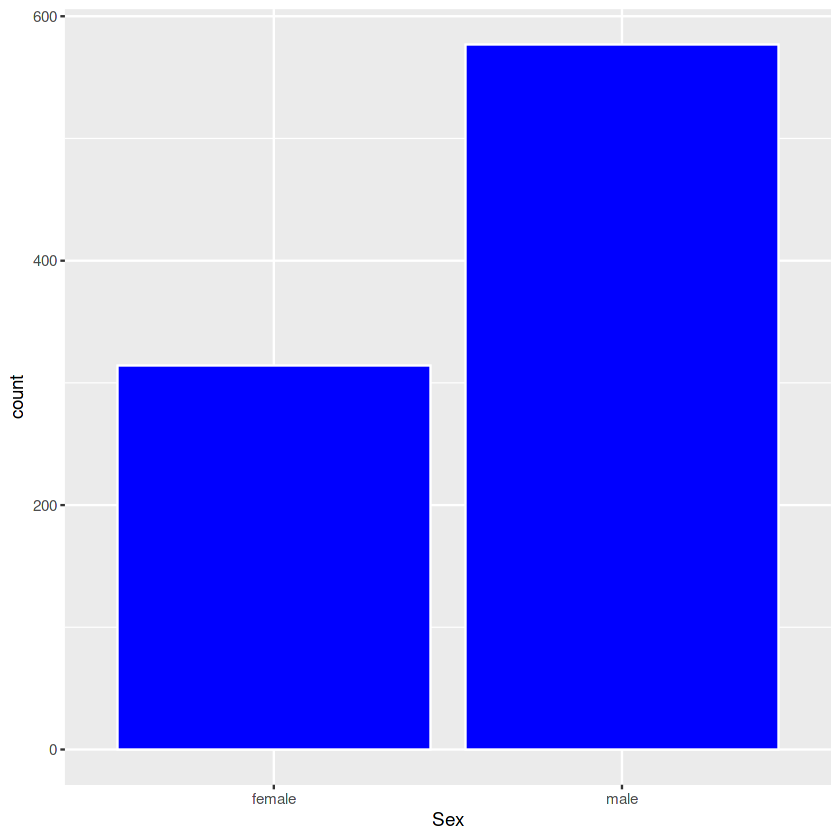

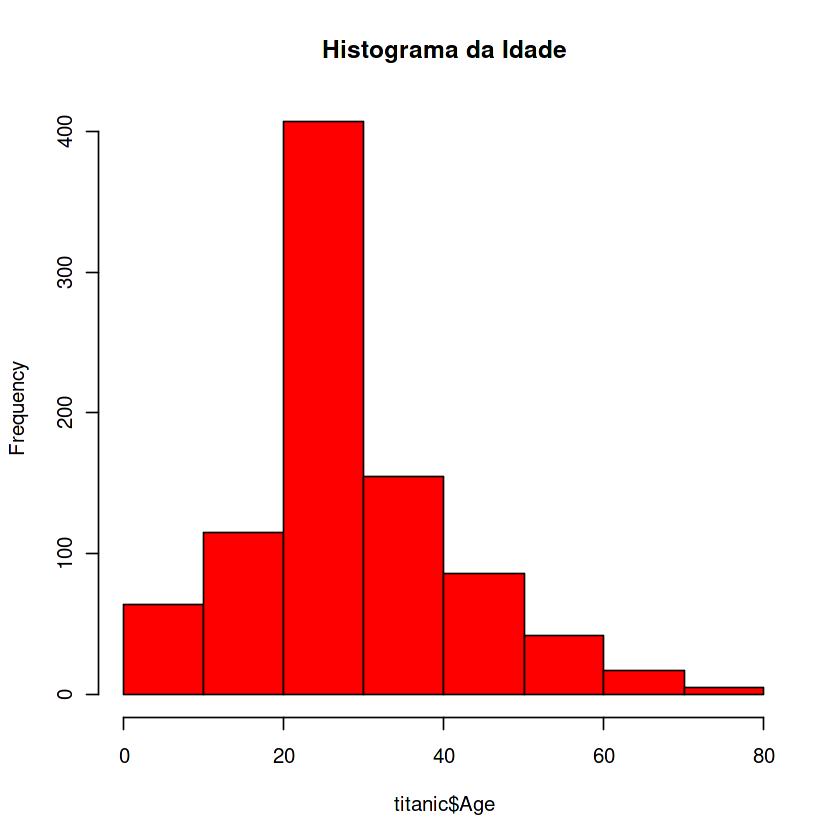

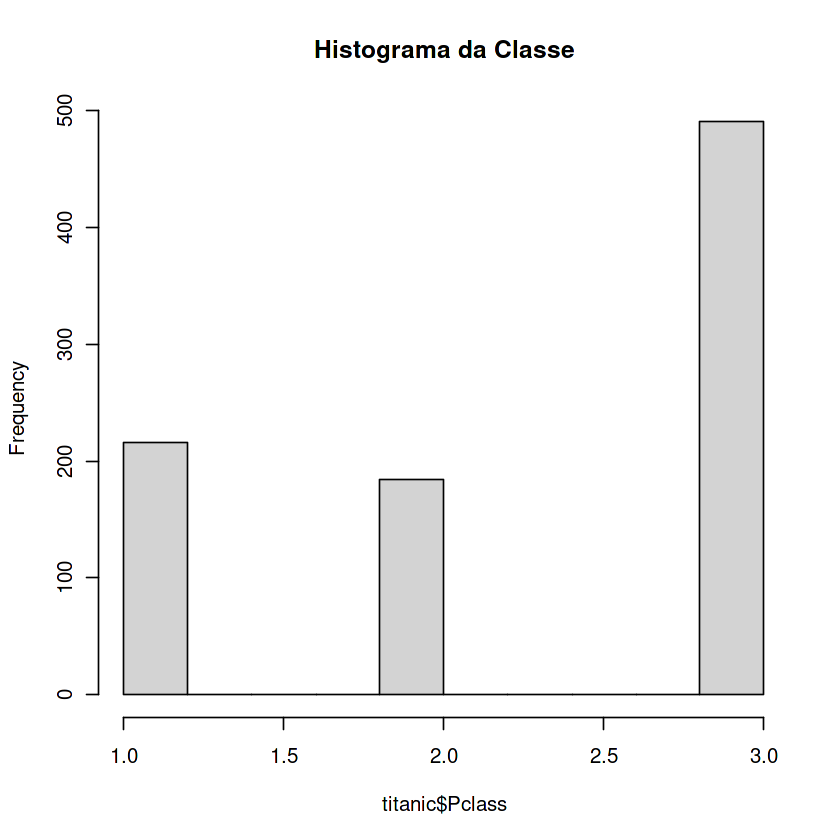

In [4]:
graf1<-ggplot(titanic, aes(x=Sex)) + 
  geom_histogram(color="white",fill = "blue", stat = "count")
graf1
graf2 <- hist(titanic$Age, col = 'red', main = "Histograma da Idade")
graf3 <- hist(titanic$Pclass, col = 'lightgray', main = "Histograma da Classe")


### Com a análise exploratória realizada, podemos começar a trabalhar com a construção de algoritmo.Primeiramente, separamos a base de dados em teste e treino para que possamos ver se o nosso modelo está conseguindo classificar corretamente as observações.Depois geramos a variável "arvore" que irá conter a nossa árvore de decisão. Com base no primeiro argumento que passamos na função, no caso se a pessoa é uma sobrevivente ou não, o algoritmo irá testar qual das outras variáveis melhor se relaciona com o fato da pessoa ter sobrevivido, como o sexo, a idade, a classe. 
### Depois, plotamos a árvore par ver o resultado que ela apresentou. 

[1] "Acurácia na base de treino: 85% "

[1] "Acurácia na base de teste: 83% "

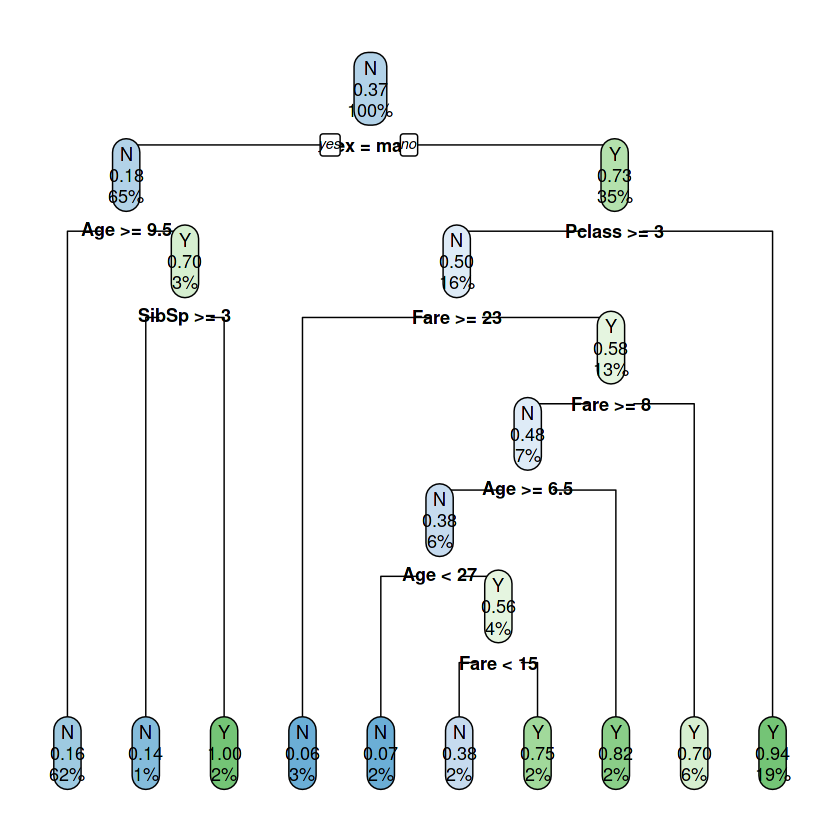

In [5]:
set.seed(123)
bool_treino <- stats::runif(dim(titanic)[1])>.25

treino <- titanic[bool_treino,]
teste  <- titanic[!bool_treino,]
set.seed(123)
arvore <- rpart(Survived ~ Pclass + Sex + Age + SibSp + Parch + Fare + Embarked,
                data=treino,
                parms = list(split = 'gini'),
                method='class'
)
rpart.plot::rpart.plot(arvore
                       )
p_treino = stats::predict(arvore, treino)
c_treino = base::factor(ifelse(p_treino[,2]>.5, "Y", "N"))
p_teste = stats::predict(arvore, teste)
c_teste = base::factor(ifelse(p_teste[,2]>.5, "Y", "N"))

tab <- table(c_treino, treino$Survived)
acc <- (tab[1,1]+tab[2,2])/nrow(treino)
sprintf('Acurácia na base de treino: %s ', percent(acc))

tab <- table(c_teste, teste$Survived)
acc <- (tab[1,1]+tab[2,2])/nrow(teste)
sprintf('Acurácia na base de teste: %s ', percent(acc))

### Com o modelo criado, podemos verificar a acurácia(pnúmero de acertos / número de tentativas) que o modelo possui de diversas maneiras. Iremos assumir que se a observação foi classificada com uma chance maior de 50% de sobreviver a pessoa será um sobrevivente, e caso seja menor de 50% a pessoa não será um sobrevivente. 
    

In [6]:
prob = predict(arvore, titanic)
class = prob[,2]>.5
tab <- table(class, titanic$Survived)
tab
df <- as.data.frame(prob)
survived <- filter(df, Y>0.5)
not_survived <- filter(df, Y<0.5)
acc <- (tab[1,1] + tab[2,2])/ sum(tab)
print(paste0('O modelo apresentou ',  nrow(survived) ,' sobreviventes'))
print(paste0('O modelo apresentou ',  nrow(not_survived) ,' não sobreviventes'))
print(paste0('A acurácia foi de:', acc))

       
class     N   Y
  FALSE 519 107
  TRUE   30 235

[1] "O modelo apresentou 265 sobreviventes"
[1] "O modelo apresentou 626 não sobreviventes"
[1] "A acurácia foi de:0.846240179573513"


### Também vemos no histograma abaixo a quantidade de acertos representados pela barra "true" e a quantidade de erros representada pela barra "false"

Warning message:
“Ignoring unknown parameters: binwidth, bins, pad”


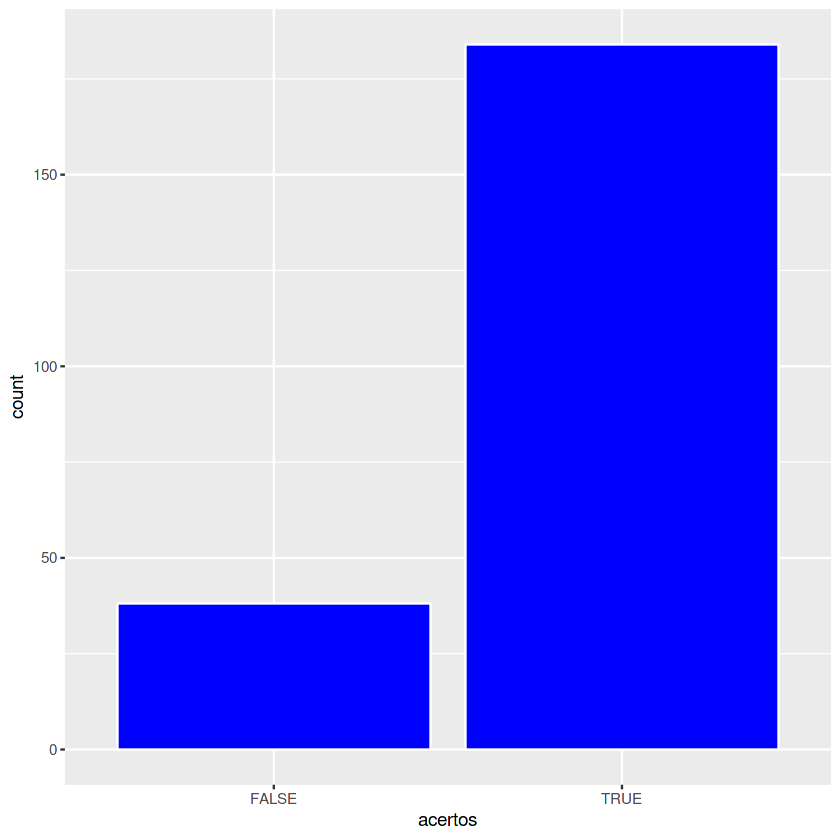

In [7]:
df5 <- as.data.frame(p_teste)
comp <- data.frame(df5)
comp['verif'] <- teste$Survived
comp$Y[comp$Y >= 0.5] <- 'Y'
comp$Y[comp$Y <= 0.5] <- 'N'
comp['acertos'] <- comp$Y == comp$verif
graf6 <- plot_ly(x=comp$acertos, type = 'histogram') %>% layout(title = 'Acurácia do Modelo')
df5 <- as.data.frame(p_teste)
comp <- data.frame(df5)
comp['verif'] <- teste$Survived
comp$Y[comp$Y >= 0.5] <- 'Y'
comp$Y[comp$Y <= 0.5] <- 'N'
comp['acertos'] <- comp$Y == comp$verif
ggplot(comp, aes(x=acertos)) + 
  geom_histogram(color="white",fill = "blue" ,stat = "count")


### Desse modo, concluimos a construção do algoritmo que é capaz de classificar futuras observações, nos dando a probabilidade de sobrevivência de determinado indivíduo com base nas suas características.